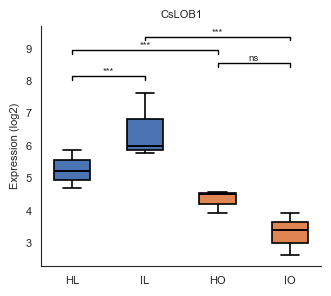

In [3]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# ==================================================
# DATA (déjà converti en HL / IL / HO / IO)
# ==================================================
data = {
    "Gene": ["CsLOB1"],

    "HL_1": [24.67012097],
    "HL_2": [36.65010624],
    "HL_3": [58.12377238],

    "IL_1": [62.84244414],
    "IL_2": [53.7092906],
    "IL_3": [199.1765068],

    "HO_1": [14.02881405],
    "HO_2": [21.83607374],
    "HO_3": [22.55758771],

    "IO_1": [5.120119285],
    "IO_2": [9.453746502],
    "IO_3": [14.29374925],
}

df = pd.DataFrame(data)

# ==================================================
# WIDE → LONG
# ==================================================
df_long = df.melt(
    id_vars="Gene",
    var_name="Sample",
    value_name="Abundance"
)

# extraire condition
df_long["Class"] = df_long["Sample"].str.extract(r"(HL|IL|HO|IO)")

# log2 transform
df_long["Abundance"] = np.log2(df_long["Abundance"] + 1)

# ==================================================
# STYLE
# ==================================================
plt.rcParams.update({
    "font.family": "Arial",
    "font.size": 8,
    "axes.labelsize": 8,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "pdf.fonttype": 42,
    "ps.fonttype": 42
})

sns.set_style("white")

color_map = {
    "HL": "#4c73b2",
    "IL": "#4c73b2",
    "HO": "#de8552",
    "IO": "#de8552"
}

order = ["HL", "IL", "HO", "IO"]
order_index = {name: i for i, name in enumerate(order)}

# ==================================================
# LOOP → 1 FIGURE PAR GENE
# ==================================================
genes = df_long["Gene"].unique()

for gene in genes:

    sub_df = df_long[df_long["Gene"] == gene]

    fig, ax = plt.subplots(figsize=(3.35, 3.0))

    # ==================================================
    # BOXPLOT (PLEIN + CONTOUR NOIR)
    # ==================================================
    for cls in order:

        subset = sub_df[sub_df["Class"] == cls]

        if len(subset) == 0:
            continue

        sns.boxplot(
            x="Class",
            y="Abundance",
            data=subset,
            order=order,
            width=0.5,
            showfliers=False,
            boxprops=dict(
                facecolor=color_map[cls],
                edgecolor="black",
                linewidth=1.2
            ),
            whiskerprops=dict(
                color="black",
                linewidth=1.2
            ),
            capprops=dict(
                color="black",
                linewidth=1.2
            ),
            medianprops=dict(
                color="black",
                linewidth=1.4
            ),
            ax=ax
        )

    # ==================================================
    # AXES
    # ==================================================
    ax.set_xticks(range(4))
    ax.set_xticklabels(order)

    ax.set_ylabel("Expression (log2)")
    ax.set_xlabel("")
    ax.set_title(gene, fontsize=8, pad=6)

    # ==================================================
    # SIGNIFICANCE (optionnel)
    # ==================================================
    comparisons = [
        ("HL", "IL", "***"),
        ("HO", "IO", "ns"),
        ("HL", "HO", "***"),
        ("IL", "IO", "***")
    ]

    y_max = sub_df["Abundance"].max()
    y_min = sub_df["Abundance"].min()
    y_range = y_max - y_min

    bar_spacing = y_range * 0.08
    bar_height = y_range * 0.02

    for i, (g1, g2, label) in enumerate(comparisons):

        x1 = order_index[g1]
        x2 = order_index[g2]

        y = y_max + bar_spacing * (i + 1)

        ax.plot(
            [x1, x1, x2, x2],
            [y, y + bar_height, y + bar_height, y],
            lw=1,
            color="black"
        )

        ax.text(
            (x1 + x2) * 0.5,
            y + bar_height,
            label,
            ha='center',
            va='bottom',
            fontsize=7
        )

    # ==================================================
    # FINAL
    # ==================================================
    sns.despine()
    plt.tight_layout()

    # ==================================================
    # EXPORT
    # ==================================================
    plt.savefig(
        f"C:/Users/tamer/Documents/PhD/ML/Gene_abundance/{gene}.pdf",
        bbox_inches="tight"
    )

    plt.savefig(
        f"C:/Users/tamer/Documents/PhD/ML/Gene_abundance/{gene}.tif",
        dpi=600,
        bbox_inches="tight"
    )
    
    plt.show()